<a href="https://colab.research.google.com/github/paulinacarvacho/paulinacarvacho-dashboard-gastronomia-chile/blob/main/fogon_del_sur_analisis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Paso 1 — Crear los datos del restaurante

In [ ]:
# ============================================================
# EL FOGÓN DEL SUR — Generador de datos de ventas
# Proyecto de portafolio | Analista: Paulina Carvacho
# ============================================================

import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

random.seed(42)
np.random.seed(42)

# --- PRODUCTOS DEL MENÚ ---
menu = [
    {"producto": "Cazuela de vacuno",   "categoria": "Almuerzo", "precio": 6500,  "costo": 2800},
    {"producto": "Pastel de choclo",    "categoria": "Almuerzo", "precio": 5800,  "costo": 2200},
    {"producto": "Plateada al horno",   "categoria": "Almuerzo", "precio": 8900,  "costo": 3500},
    {"producto": "Merluza frita",       "categoria": "Almuerzo", "precio": 7200,  "costo": 2900},
    {"producto": "Cordero patagónico",  "categoria": "Cena",     "precio": 12500, "costo": 5200},
    {"producto": "Lomo a lo pobre",     "categoria": "Cena",     "precio": 10800, "costo": 4100},
    {"producto": "Empanadas (3 und.)",  "categoria": "Cena",     "precio": 4500,  "costo": 1600},
    {"producto": "Agua mineral",        "categoria": "Bebidas",  "precio": 1200,  "costo": 350},
    {"producto": "Jugo natural",        "categoria": "Bebidas",  "precio": 2200,  "costo": 600},
    {"producto": "Cerveza artesanal",   "categoria": "Bebidas",  "precio": 3800,  "costo": 1100},
    {"producto": "Kuchen de murta",     "categoria": "Postres",  "precio": 2800,  "costo": 900},
    {"producto": "Leche asada",         "categoria": "Postres",  "precio": 2200,  "costo": 700},
]

metodos_pago = ["Efectivo", "Débito", "Crédito"]

# --- GENERAR 3 MESES DE VENTAS ---
fecha_inicio = datetime(2024, 10, 1)
registros = []

for dia in range(92):  # Oct, Nov, Dic 2024
    fecha = fecha_inicio + timedelta(days=dia)
    dia_semana = fecha.weekday()  # 0=Lunes, 6=Domingo

    # Más ventas fines de semana (realista para un restaurante)
    ventas_del_dia = random.randint(18, 25) if dia_semana >= 4 else random.randint(8, 15)

    for _ in range(ventas_del_dia):
        item = random.choice(menu)

        # Horario según categoría
        if item["categoria"] == "Almuerzo":
            hora = f"{random.randint(12,14):02d}:{random.choice(['00','30'])}"
        elif item["categoria"] == "Cena":
            hora = f"{random.randint(19,22):02d}:{random.choice(['00','30'])}"
        else:
            hora = f"{random.randint(12,22):02d}:{random.choice(['00','30'])}"

        cantidad = random.randint(1, 3)

        registros.append({
            "fecha":           fecha.strftime("%Y-%m-%d"),
            "dia_semana":      ["Lun","Mar","Mié","Jue","Vie","Sáb","Dom"][dia_semana],
            "hora":            hora,
            "categoria":       item["categoria"],
            "producto":        item["producto"],
            "cantidad":        cantidad,
            "precio_unitario": item["precio"],
            "costo_unitario":  item["costo"],
            "venta_total":     item["precio"] * cantidad,
            "costo_total":     item["costo"] * cantidad,
            "metodo_pago":     random.choices(metodos_pago, weights=[30,50,20])[0]
        })

df = pd.DataFrame(registros)
df["margen"] = df["venta_total"] - df["costo_total"]
df["margen_pct"] = ((df["margen"] / df["venta_total"]) * 100).round(1)

print(f"✅ Dataset creado: {len(df)} registros")
print(f"📅 Período: {df['fecha'].min()} → {df['fecha'].max()}")
print(f"💰 Venta total del período: ${df['venta_total'].sum():,.0f} CLP")
print(f"📊 Margen total del período: ${df['margen'].sum():,.0f} CLP")
print()
df.head(10)

✅ Dataset creado: 1438 registros
📅 Período: 2024-10-01 → 2024-12-31
💰 Venta total del período: $16,072,500 CLP
📊 Margen total del período: $10,016,100 CLP



,fecha,dia_semana,hora,categoria,producto,cantidad,precio_unitario,costo_unitario,venta_total,costo_total,metodo_pago,margen,margen_pct
0,2024-10-01,Mar,14:30,Almuerzo,Cazuela de vacuno,1,6500,2800,6500,2800,Efectivo,3700,56.9
1,2024-10-01,Mar,13:00,Postres,Leche asada,3,2200,700,6600,2100,Débito,4500,68.2
2,2024-10-01,Mar,12:00,Almuerzo,Cazuela de vacuno,1,6500,2800,6500,2800,Débito,3700,56.9
3,2024-10-01,Mar,14:00,Almuerzo,Cazuela de vacuno,3,6500,2800,19500,8400,Débito,11100,56.9
4,2024-10-01,Mar,18:00,Bebidas,Jugo natural,2,2200,600,4400,1200,Débito,3200,72.7
5,2024-10-01,Mar,12:30,Almuerzo,Cazuela de vacuno,2,6500,2800,13000,5600,Efectivo,7400,56.9
6,2024-10-01,Mar,13:00,Almuerzo,Merluza frita,1,7200,2900,7200,2900,Débito,4300,59.7
7,2024-10-01,Mar,21:30,Cena,Lomo a lo pobre,1,10800,4100,10800,4100,Débito,6700,62.0
8,2024-10-01,Mar,13:30,Bebidas,Jugo natural,1,2200,600,2200,600,Débito,1600,72.7
9,2024-10-02,Mié,15:00,Bebidas,Cerveza artesanal,1,3800,1100,3800,1100,Débito,2700,71.1


Paso 2 - Analisis

In [ ]:
# ============================================================
# ANÁLISIS DE NEGOCIO — El Fogón del Sur
# ============================================================

# --- PREGUNTA 1: ¿Cuáles son los días de mayor venta? ---
ventas_por_dia = (
    df.groupby("dia_semana")["venta_total"]
    .sum()
    .reindex(["Lun","Mar","Mié","Jue","Vie","Sáb","Dom"])
)

print("=" * 45)
print("📅 VENTAS POR DÍA DE LA SEMANA")
print("=" * 45)
for dia, venta in ventas_por_dia.items():
    barra = "█" * int(venta / 50000)
    print(f"{dia:>4}  ${venta:>10,.0f}  {barra}")

# --- PREGUNTA 2: ¿Qué productos son más rentables? ---
rentabilidad = (
    df.groupby("producto")
    .agg(
        venta_total   = ("venta_total", "sum"),
        margen_total  = ("margen", "sum"),
        unidades      = ("cantidad", "sum"),
        margen_pct    = ("margen_pct", "mean")
    )
    .sort_values("margen_total", ascending=False)
    .reset_index()
)

print("\n" + "=" * 45)
print("🍽  TOP 5 PRODUCTOS MÁS RENTABLES")
print("=" * 45)
print(rentabilidad[["producto","venta_total","margen_total","margen_pct"]].head(5).to_string(index=False))

# --- PREGUNTA 3: ¿Cómo está el flujo de caja mensual? ---
df["mes"] = pd.to_datetime(df["fecha"]).dt.strftime("%b %Y")

flujo_mensual = (
    df.groupby("mes")
    .agg(
        ingresos = ("venta_total", "sum"),
        costos   = ("costo_total", "sum"),
        margen   = ("margen", "sum")
    )
    .reset_index()
)
flujo_mensual["rentabilidad_%"] = ((flujo_mensual["margen"] / flujo_mensual["ingresos"]) * 100).round(1)

print("\n" + "=" * 45)
print("💸 FLUJO DE CAJA MENSUAL")
print("=" * 45)
print(flujo_mensual.to_string(index=False))

# --- PREGUNTA 4: ¿Tendencia preocupante? ---
ventas_semana = (
    df.assign(semana = pd.to_datetime(df["fecha"]).dt.isocalendar().week)
    .groupby("semana")["venta_total"]
    .sum()
    .reset_index()
)
tendencia = "📈 Al alza" if ventas_semana["venta_total"].iloc[-1] > ventas_semana["venta_total"].iloc[0] else "📉 A la baja"

print("\n" + "=" * 45)
print("📉 TENDENCIA DE VENTAS")
print("=" * 45)
print(f"Primera semana: ${ventas_semana['venta_total'].iloc[0]:,.0f} CLP")
print(f"Última semana:  ${ventas_semana['venta_total'].iloc[-1]:,.0f} CLP")
print(f"Tendencia: {tendencia}")

# --- GUARDAR PARA EL DASHBOARD ---
df.to_csv("ventas_fogon_del_sur.csv", index=False)
print("\n✅ Datos exportados → ventas_fogon_del_sur.csv")

📅 VENTAS POR DÍA DE LA SEMANA
 Lun  $ 1,664,500  █████████████████████████████████
 Mar  $ 1,776,800  ███████████████████████████████████
 Mié  $ 1,498,800  █████████████████████████████
 Jue  $ 1,553,600  ███████████████████████████████
 Vie  $ 3,175,700  ███████████████████████████████████████████████████████████████
 Sáb  $ 3,290,200  █████████████████████████████████████████████████████████████████
 Dom  $ 3,112,900  ██████████████████████████████████████████████████████████████

🍽  TOP 5 PRODUCTOS MÁS RENTABLES
          producto  venta_total  margen_total  margen_pct
   Lomo a lo pobre      2894400       1795600        62.0
 Plateada al horno      2385200       1447200        60.7
Cordero patagónico      2275000       1328600        58.4
  Pastel de choclo      1600800        993600        62.1
     Merluza frita      1512000        903000        59.7

💸 FLUJO DE CAJA MENSUAL
     mes  ingresos  costos  margen  rentabilidad_%
Dec 2024   5005900 1883300 3122600            62.4
Nov

Paso 3 - Graficos

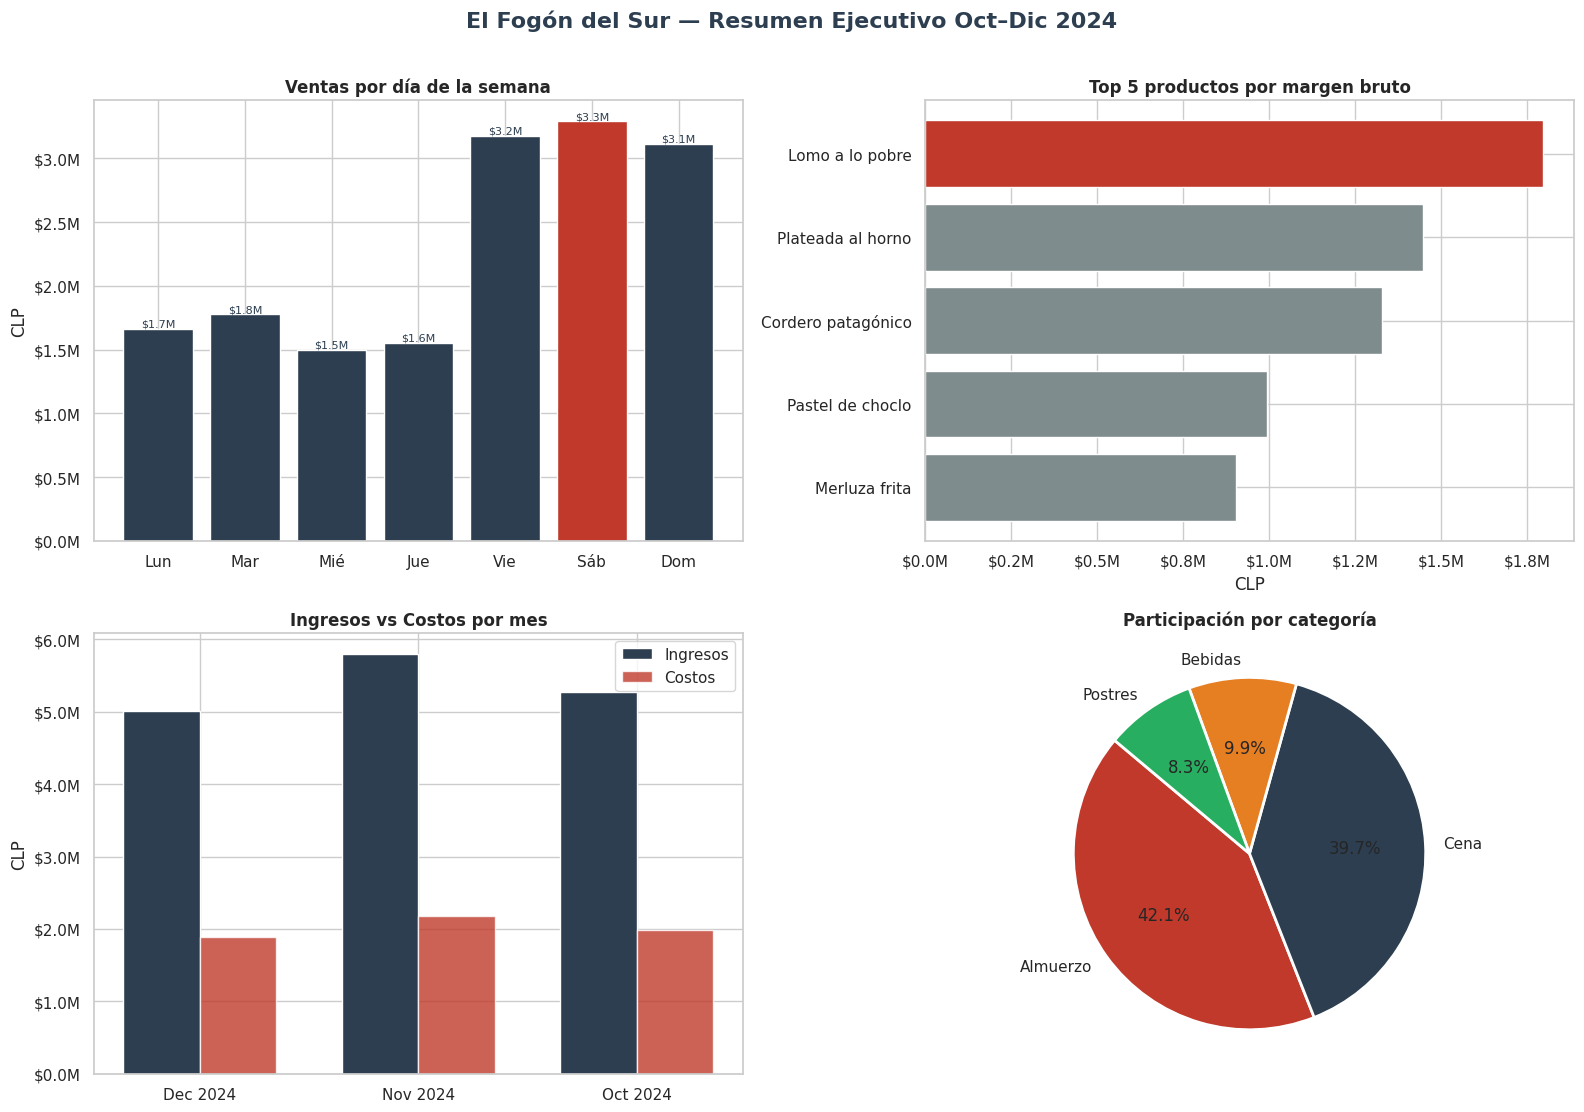

✅ Gráfico guardado → dashboard_fogon_del_sur.png


In [ ]:
# ============================================================
# VISUALIZACIONES — El Fogón del Sur
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
COLOR_PRINCIPAL = "#C0392B"  # rojo vino — identidad del restaurante
COLOR_SECUNDARIO = "#2C3E50"

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("El Fogón del Sur — Resumen Ejecutivo Oct–Dic 2024",
             fontsize=16, fontweight="bold", color=COLOR_SECUNDARIO, y=1.01)

# ── GRÁFICO 1: Ventas por día de la semana ──────────────────
ax1 = axes[0, 0]
colores = [COLOR_PRINCIPAL if d == "Sáb" else COLOR_SECUNDARIO for d in ventas_por_dia.index]
bars = ax1.bar(ventas_por_dia.index, ventas_por_dia.values, color=colores, edgecolor="white")
ax1.set_title("Ventas por día de la semana", fontweight="bold")
ax1.set_ylabel("CLP")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15000,
             f"${bar.get_height()/1e6:.1f}M", ha="center", fontsize=8, color=COLOR_SECUNDARIO)

# ── GRÁFICO 2: Top 5 productos por margen ──────────────────
ax2 = axes[0, 1]
top5 = rentabilidad.head(5)
colores2 = [COLOR_PRINCIPAL if p == "Lomo a lo pobre" else "#7F8C8D" for p in top5["producto"]]
ax2.barh(top5["producto"], top5["margen_total"], color=colores2, edgecolor="white")
ax2.set_title("Top 5 productos por margen bruto", fontweight="bold")
ax2.set_xlabel("CLP")
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
ax2.invert_yaxis()

# ── GRÁFICO 3: Flujo mensual — Ingresos vs Costos ──────────
ax3 = axes[1, 0]
x = range(len(flujo_mensual))
width = 0.35
ax3.bar([i - width/2 for i in x], flujo_mensual["ingresos"],
        width=width, label="Ingresos", color=COLOR_SECUNDARIO)
ax3.bar([i + width/2 for i in x], flujo_mensual["costos"],
        width=width, label="Costos", color=COLOR_PRINCIPAL, alpha=0.8)
ax3.set_xticks(list(x))
ax3.set_xticklabels(flujo_mensual["mes"])
ax3.set_title("Ingresos vs Costos por mes", fontweight="bold")
ax3.set_ylabel("CLP")
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
ax3.legend()

# ── GRÁFICO 4: Ventas por categoría ────────────────────────
ax4 = axes[1, 1]
ventas_cat = df.groupby("categoria")["venta_total"].sum().sort_values(ascending=False)
wedge_props = {"edgecolor": "white", "linewidth": 2}
ax4.pie(ventas_cat.values,
        labels=ventas_cat.index,
        autopct="%1.1f%%",
        colors=[COLOR_PRINCIPAL, COLOR_SECUNDARIO, "#E67E22", "#27AE60"],
        wedgeprops=wedge_props,
        startangle=140)
ax4.set_title("Participación por categoría", fontweight="bold")

plt.tight_layout()
plt.savefig("dashboard_fogon_del_sur.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfico guardado → dashboard_fogon_del_sur.png")

Paso 4 - Exportar a google sheets

In [ ]:
# Descargar el archivo CSV a tu computador
from google.colab import files
files.download("ventas_fogon_del_sur.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>